# INSTALL & IMPORT LIBRARIES

In [ ]:
# Install TensorFlow Datasets (usually preinstalled in Colab)
!pip install tensorflow-datasets


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ReduceLROnPlateau


# LOAD DATASET (PLANTVILLAGE)

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

# ================================
# 1. Load PlantVillage Dataset
#    80% Train, 10% Validation, 10% Test
# ================================

dataset_name = "plant_village"

(ds_train, ds_val, ds_test), ds_info = tfds.load(
    dataset_name,
    split=[
        "train[:80%]",      # 80% Training
        "train[80%:90%]",   # 10% Validation
        "train[90%:]"       # 10% Testing
    ],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

# ================================
# 2. Get All Class Names
# ================================

all_class_names = ds_info.features['label'].names

# ================================
# 3. Identify Apple Classes Only
# ================================

apple_class_names_list = sorted([
    cls for cls in all_class_names if cls.startswith("Apple___")
])

# Create mapping from original label index → new Apple-only index
apple_class_to_new_index = {
    name: idx for idx, name in enumerate(apple_class_names_list)
}

# ================================
# 4. Filtering Predicate (Apple Only)
# ================================

def is_apple_class(image, label):
    def _is_apple(lbl):
        return all_class_names[lbl.numpy()].startswith("Apple___")

    return tf.py_function(
        func=_is_apple,
        inp=[label],
        Tout=tf.bool
    )

# ================================
# 5. Remap Labels to New Indices
# ================================

def filter_and_remap_apple_classes(image, label):
    def _remap_label(lbl):
        original_label_name = all_class_names[lbl.numpy()]
        return apple_class_to_new_index[original_label_name]

    new_label = tf.py_function(
        func=_remap_label,
        inp=[label],
        Tout=tf.int64
    )

    # Important: restore shape info
    new_label.set_shape([])

    return image, new_label

# ================================
# 6. Apply Filter & Remap to All Splits
# ================================

ds_train = ds_train.filter(is_apple_class).map(filter_and_remap_apple_classes)
ds_val   = ds_val.filter(is_apple_class).map(filter_and_remap_apple_classes)
ds_test  = ds_test.filter(is_apple_class).map(filter_and_remap_apple_classes)

# ================================
# 7. Final Class Info
# ================================

class_names = apple_class_names_list
num_classes = len(class_names)

print("Apple-only classes:")
for i, cls in enumerate(class_names):
    print(f"{i}: {cls}")

print("\nNumber of Apple classes:", num_classes)



Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.CFANNC_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
Apple-only classes:
0: Apple___Apple_scab
1: Apple___Black_rot
2: Apple___Cedar_apple_rust
3: Apple___healthy

Number of Apple classes: 4


# PREPROCESSING

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess(image, label):
    # Resize image
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    # Convert to float
    image = tf.cast(image, tf.float32)

    # 🔹 Random horizontal flip
    image = tf.image.random_flip_left_right(image)

    # 🔹 Increase contrast
    image = tf.image.adjust_contrast(image, contrast_factor=1.2)

    # 🔹 Increase brightness
    image = tf.image.adjust_brightness(image, delta=0.08)

    # 🔹 Clip to avoid overexposure
    image = tf.clip_by_value(image, 0.0, 255.0)

    # Normalize to [0,1]
    image = image / 255.0

    return image, label

# Apply preprocessing
ds_train = ds_train.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_val = ds_val.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


# VISUALIZE SAMPLE IMAGES

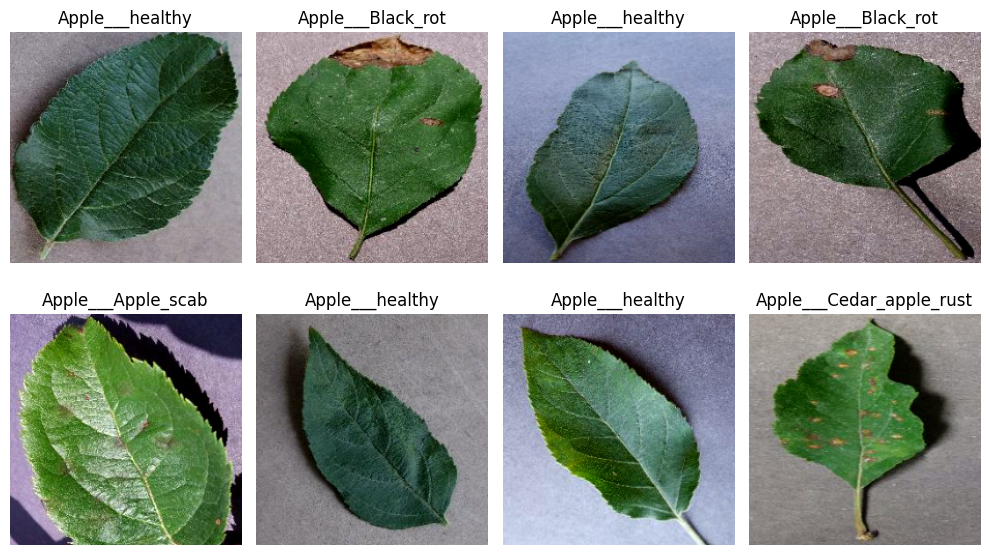

In [ ]:
plt.figure(figsize=(10,6))

for images, labels in ds_train.take(1):
    for i in range(8):
        plt.subplot(2,4,i+1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()



# CLASS DISTRIBUTION

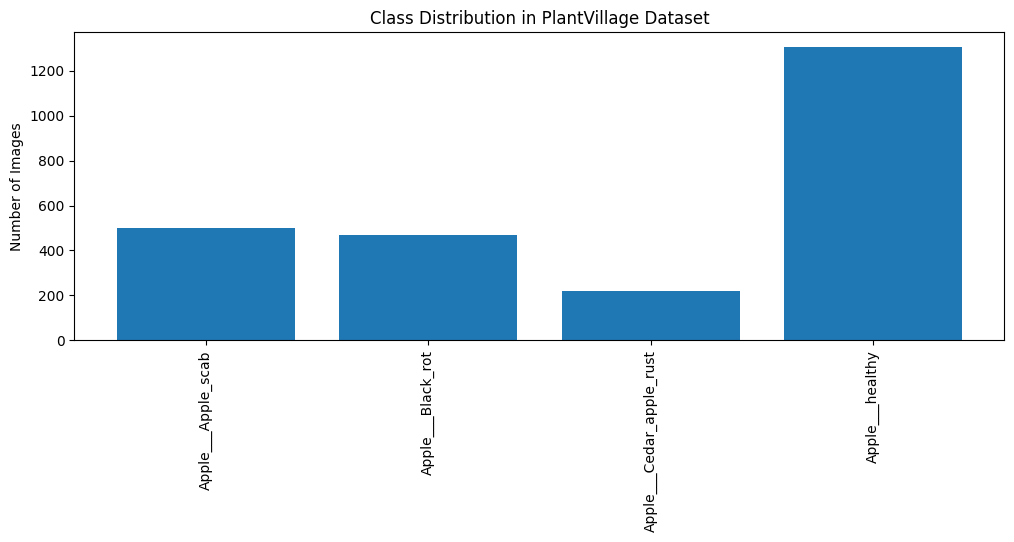

In [ ]:
label_counts = np.zeros(num_classes)

for _, label in tfds.as_numpy(ds_train.unbatch()):
    label_counts[label] += 1

plt.figure(figsize=(12,4))
plt.bar(class_names, label_counts)
plt.xticks(rotation=90)
plt.title("Class Distribution in PlantVillage Dataset")
plt.ylabel("Number of Images")
plt.show()


# CUSTOM CNN ARCHITECTURE

In [ ]:
custom_cnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.BatchNormalization(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.BatchNormalization(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

custom_cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 111, 111, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 54, 54, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,372 (42.61 MB)

 Trainable params: 11,169,924 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

# TRAIN CUSTOM CNN

In [ ]:
callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6)
]

history_custom = custom_cnn.fit(
    ds_train,
    validation_data=ds_val,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15
     78/Unknown 53s 547ms/step - accuracy: 0.7713 - loss: 2.2247

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


78/78 ━━━━━━━━━━━━━━━━━━━━ 59s 630ms/step - accuracy: 0.7721 - loss: 2.2146 - val_accuracy: 0.4878 - val_loss: 10.0215 - learning_rate: 5.0000e-04
Epoch 2/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 42s 544ms/step - accuracy: 0.8890 - loss: 0.4357 - val_accuracy: 0.1518 - val_loss: 13.7369 - learning_rate: 5.0000e-04
Epoch 3/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 41s 529ms/step - accuracy: 0.8903 - loss: 0.4235 - val_accuracy: 0.5149 - val_loss: 20.8956 - learning_rate: 5.0000e-04
Epoch 4/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 42s 545ms/step - accuracy: 0.9032 - loss: 0.3719 - val_accuracy: 0.4905 - val_loss: 23.1951 - learning_rate: 5.0000e-04
Epoch 5/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 41s 530ms/step - accuracy: 0.9159 - loss: 0.2691 - val_accuracy: 0.5854 - val_loss: 6.7246 - learning_rate: 1.5000e-04
Epoch 6/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 41s 532ms/step - accuracy: 0.9402 - loss: 0.1611 - val_accuracy: 0.6070 - val_loss: 5.7512 - learning_rate: 1.5000e-04
Epoch 7/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 42s 542ms/step - accuracy: 

# PHASE 1 (FEATURE EXTRACTION)

In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# TRAIN PHASE 1

In [ ]:
history_tl_1 = transfer_model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 83s 841ms/step - accuracy: 0.7957 - loss: 0.6087 - val_accuracy: 0.9919 - val_loss: 0.0491 - learning_rate: 0.0010
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 40s 516ms/step - accuracy: 0.9658 - loss: 0.0994 - val_accuracy: 0.9783 - val_loss: 0.0492 - learning_rate: 0.0010
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 41s 524ms/step - accuracy: 0.9873 - loss: 0.0488 - val_accuracy: 0.9946 - val_loss: 0.0236 - learning_rate: 0.0010
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 499ms/step - accuracy: 0.9816 - loss: 0.0483 - val_accuracy: 0.9837 - val_loss: 0.0319 - learning_rate: 0.0010
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 502ms/step - accuracy: 0.9884 - loss: 0.0453 - val_accuracy: 0.9946 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 503ms/step - accuracy: 0.9914 - loss: 0.0282 - val_accuracy: 1.0000 - val_loss: 0.0144 - learning_rate: 0.0010
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 40s 513ms/step - accuracy: 0.9885 - loss: 0.

# PHASE 2 (FINE-TUNING)

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_tl_2 = transfer_model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=15,
    callbacks=callbacks
)



Epoch 1/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 130s 704ms/step - accuracy: 0.9514 - loss: 0.1575 - val_accuracy: 0.9864 - val_loss: 0.0319 - learning_rate: 1.0000e-05
Epoch 2/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 40s 510ms/step - accuracy: 0.9738 - loss: 0.0826 - val_accuracy: 0.9864 - val_loss: 0.0512 - learning_rate: 1.0000e-05
Epoch 3/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 40s 512ms/step - accuracy: 0.9896 - loss: 0.0410 - val_accuracy: 0.9756 - val_loss: 0.0938 - learning_rate: 1.0000e-05
Epoch 4/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 40s 517ms/step - accuracy: 0.9787 - loss: 0.0472 - val_accuracy: 0.9729 - val_loss: 0.0976 - learning_rate: 1.0000e-05
Epoch 5/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 40s 513ms/step - accuracy: 0.9930 - loss: 0.0218 - val_accuracy: 0.9783 - val_loss: 0.0836 - learning_rate: 3.0000e-06
Epoch 6/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.9964 - loss: 0.0163 - val_accuracy: 0.9837 - val_loss: 0.0634 - learning_rate: 3.0000e-06
Epoch 7/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 40s 517ms/step - accur

# ACCURACY COMPARISON

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


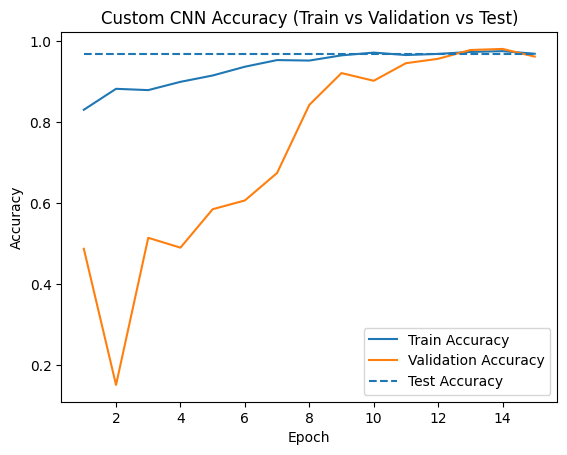

In [ ]:
# Evaluate Custom CNN on test set
test_loss_custom, test_acc_custom = custom_cnn.evaluate(ds_test, verbose=0)

epochs_custom = range(1, len(history_custom.history["accuracy"]) + 1)

plt.figure()
plt.plot(epochs_custom, history_custom.history["accuracy"], label="Train Accuracy")
plt.plot(epochs_custom, history_custom.history["val_accuracy"], label="Validation Accuracy")
plt.hlines(
    test_acc_custom,
    xmin=1,
    xmax=len(epochs_custom),
    linestyles="dashed",
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN Accuracy (Train vs Validation vs Test)")
plt.legend()
plt.show()

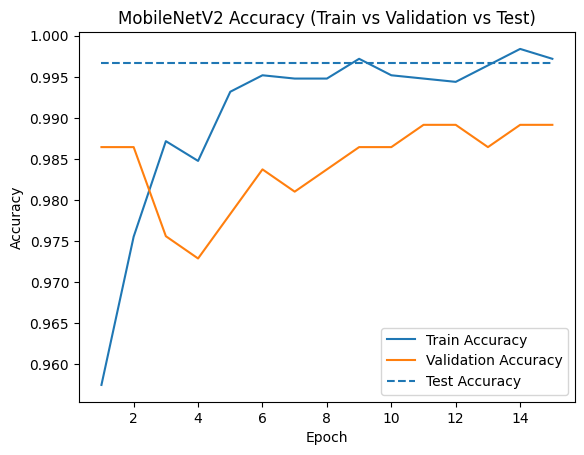

In [ ]:
# Evaluate MobileNetV2 on test set
test_loss_tl, test_acc_tl = transfer_model.evaluate(ds_test, verbose=0)

epochs_tl = range(1, len(history_tl_2.history["accuracy"]) + 1)

plt.figure()
plt.plot(epochs_tl, history_tl_2.history["accuracy"], label="Train Accuracy")
plt.plot(epochs_tl, history_tl_2.history["val_accuracy"], label="Validation Accuracy")
plt.hlines(
    test_acc_tl,
    xmin=1,
    xmax=len(epochs_tl),
    linestyles="dashed",
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Accuracy (Train vs Validation vs Test)")
plt.legend()
plt.show()


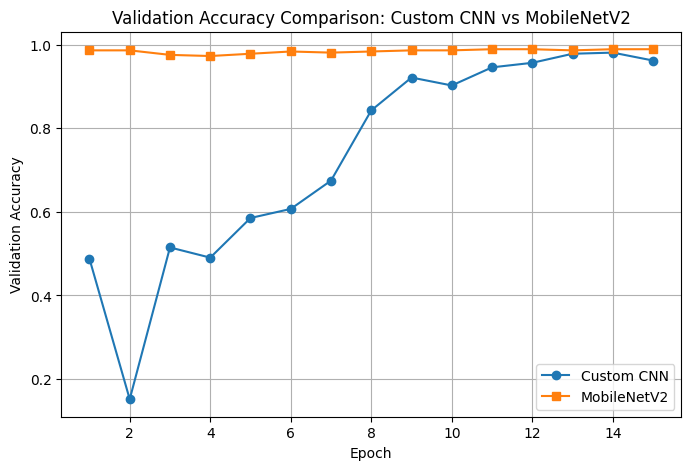

In [ ]:
import matplotlib.pyplot as plt

# Get number of epochs for each model
epochs_custom = range(1, len(history_custom.history["val_accuracy"]) + 1)
epochs_tl = range(1, len(history_tl_2.history["val_accuracy"]) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_custom, history_custom.history["val_accuracy"], marker='o', label="Custom CNN")
plt.plot(epochs_tl, history_tl_2.history["val_accuracy"], marker='s', label="MobileNetV2")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison: Custom CNN vs MobileNetV2")
plt.legend()
plt.grid(True)
plt.show()


# CONFUSION MATRIX

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,          # ✅ show numbers
        fmt="d",             # ✅ integer values
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5,
        linecolor="gray"
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# CONFUSION MATRIX (CUSTOM CNN)

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 329ms/step


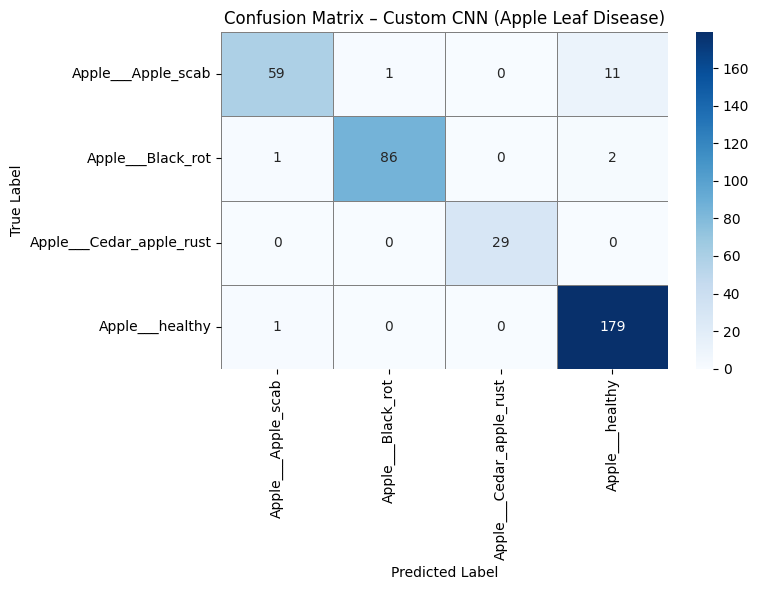

In [ ]:
# Custom CNN

y_true_cnn = np.concatenate([y for x, y in ds_val], axis=0)
y_pred_cnn = np.argmax(custom_cnn.predict(ds_val), axis=1)

plot_confusion_matrix(
    y_true_cnn,
    y_pred_cnn,
    class_names,
    "Confusion Matrix – Custom CNN (Apple Leaf Disease)"
)


# CONFUSION MATRIX (TRANSFER MODEL)

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 662ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


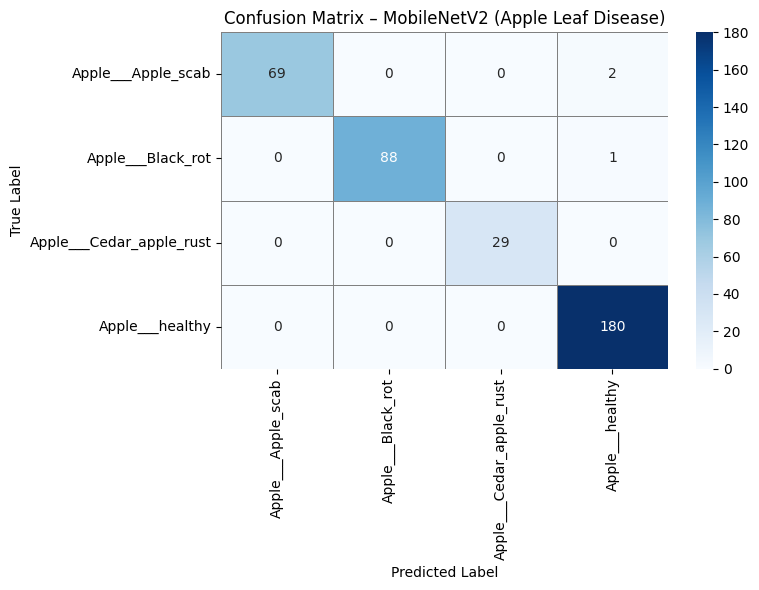

In [ ]:

# MobileNetV2
y_true_tl = np.concatenate([y for x, y in ds_val], axis=0)
y_pred_tl = np.argmax(transfer_model.predict(ds_val), axis=1)

plot_confusion_matrix(
    y_true_tl,
    y_pred_tl,
    class_names,
    "Confusion Matrix – MobileNetV2 (Apple Leaf Disease)"
)


# Model Evaluation

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 342ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 384ms/step
===== Custom CNN Performance Metrics =====
Accuracy: 0.9214
Precision: 0.9219
Recall: 0.9214
F1-Score: 0.9206



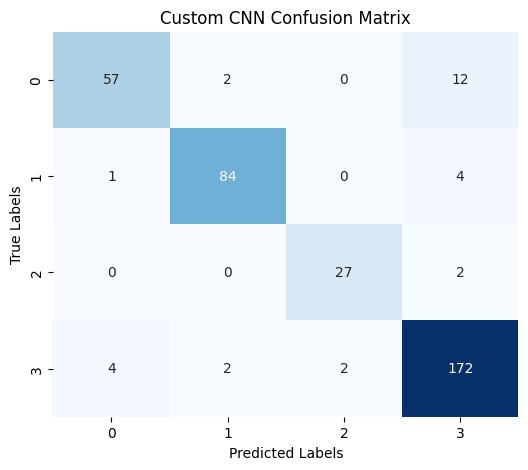

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        71
           1       0.95      0.94      0.95        89
           2       0.93      0.93      0.93        29
           3       0.91      0.96      0.93       180

    accuracy                           0.92       369
   macro avg       0.93      0.91      0.92       369
weighted avg       0.92      0.92      0.92       369




===== MobileNetV2 Transfer Learning Performance Metrics =====
Accuracy: 0.9864
Precision: 0.9868
Recall: 0.9864
F1-Score: 0.9864



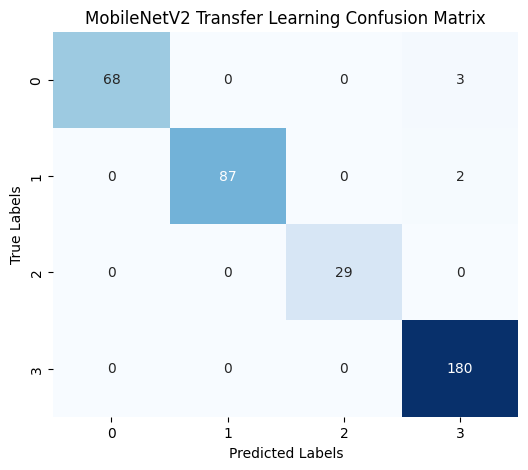

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        71
           1       1.00      0.98      0.99        89
           2       1.00      1.00      1.00        29
           3       0.97      1.00      0.99       180

    accuracy                           0.99       369
   macro avg       0.99      0.98      0.99       369
weighted avg       0.99      0.99      0.99       369






In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming ds_val is a tf.data.Dataset
# Extract true labels and predictions for evaluation
y_true = np.concatenate([y for x, y in ds_val], axis=0)

# 1️⃣ Predictions for Custom CNN
y_pred_custom = custom_cnn.predict(ds_val)
y_pred_custom = np.argmax(y_pred_custom, axis=1)  # convert probabilities to class labels

# 2️⃣ Predictions for Transfer Learning Model (MobileNet)
y_pred_tl = transfer_model.predict(ds_val)
y_pred_tl = np.argmax(y_pred_tl, axis=1)

# Function to compute and display metrics
def evaluate_model(y_true, y_pred, model_name):
    print(f"===== {model_name} Performance Metrics =====")
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}\n")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    print("\n\n")

# Evaluate both models
evaluate_model(y_true, y_pred_custom, "Custom CNN")
evaluate_model(y_true, y_pred_tl, "MobileNetV2 Transfer Learning")


# DEMO PREDICTION

Saving images (1).jpg to images (1) (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


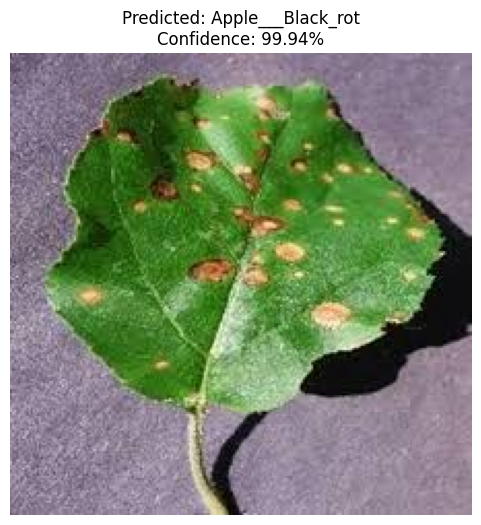

Predicted Class: Apple___Black_rot
Confidence Score: 99.94%


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for file_name in uploaded.keys():
    # Load image
    img = load_img(file_name, target_size=(224, 224))
    img_array = img_to_array(img)

    # 🔴 IMPORTANT FIX: SAME preprocessing as training
    img_array = img_array / 255.0   # NOT preprocess_input
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = transfer_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_label = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    # Display
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_label}\nConfidence: {confidence:.2f}%")
    plt.show()

    print("Predicted Class:", predicted_label)
    print(f"Confidence Score: {confidence:.2f}%")


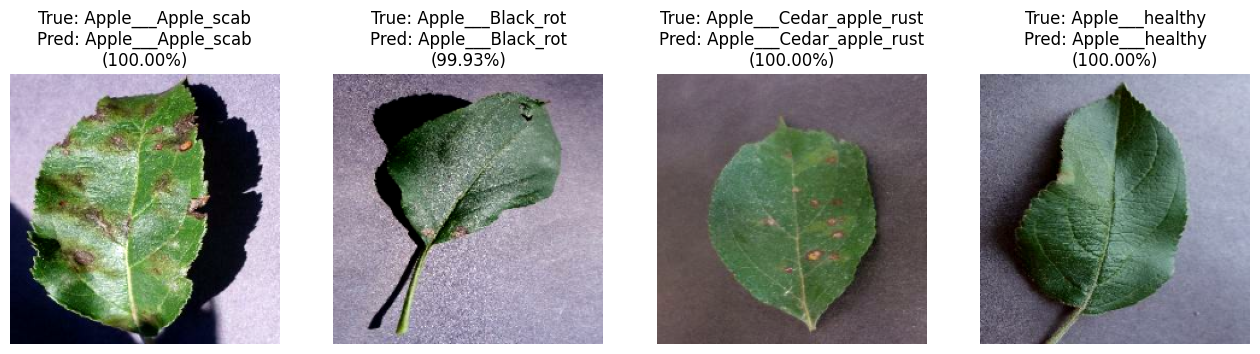

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Number of classes
num_classes = len(class_names)

# Dictionary to store one image per class
class_images = {}

# Iterate over the test dataset
for images_batch, labels_batch in ds_test.as_numpy_iterator():
    for img, lbl in zip(images_batch, labels_batch):
        lbl_int = int(lbl)
        if lbl_int not in class_images:
            # Store the first image found for this class
            class_images[lbl_int] = img
        # Stop if we already have one image for all classes
        if len(class_images) == num_classes:
            break
    if len(class_images) == num_classes:
        break

# Create a figure
plt.figure(figsize=(16, 4))

for class_idx in range(num_classes):
    img = class_images[class_idx]
    true_label = class_names[class_idx]

    # Predict using the transfer learning model
    prediction = transfer_model.predict(np.expand_dims(img, axis=0), verbose=0)
    predicted_index = np.argmax(prediction)
    predicted_label = class_names[predicted_index]
    confidence = np.max(prediction) * 100

    # Plot the image
    plt.subplot(1, num_classes, class_idx + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True: {true_label}\nPred: {predicted_label}\n({confidence:.2f}%)")


plt.show()